# Task 1 — Data Exploration and 10% Sampling

This notebook explores the aligned English–Spanish Europarl corpus and creates the 10% sample required for the later tasks.

Only necessary files are written to disk:

- plots are saved in `plots/task01/`,
- the sampled English and Spanish corpora are saved in `data/sampled/`.

The numerical summaries remain inside the notebook and are not exported as JSON or CSV files.


In [3]:
from pathlib import Path
from itertools import zip_longest
from array import array

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

RANDOM_SEED = 43
SAMPLE_FRACTION = 0.10

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data"
PLOT_DIR = PROJECT_ROOT / "plots" / "task01"
SAMPLE_DIR = DATA_DIR / "sampled"

EN_PATH = DATA_DIR / "europarl-v7.es-en.en"
ES_PATH = DATA_DIR / "europarl-v7.es-en.es"

print(f"Project root: {PROJECT_ROOT}")


Project root: /home/theohagen/Desktop/nlp-machine-translation


## 1. Read the aligned corpus and collect statistics

The files are processed line by line so that the complete corpus does not have to be loaded into memory as text. Each English line must correspond to the Spanish line with the same index.


In [5]:
en_token_lengths = array("I")
es_token_lengths = array("I")
en_char_lengths = array("I")
es_char_lengths = array("I")

empty_en = 0
empty_es = 0
empty_pair = 0
total_pairs = 0

with EN_PATH.open("r", encoding="utf-8", errors="replace") as en_file, \
     ES_PATH.open("r", encoding="utf-8", errors="replace") as es_file:

    aligned_lines = zip_longest(en_file, es_file, fillvalue=None)

    for index, (en_line, es_line) in enumerate(
        tqdm(aligned_lines, desc="Reading aligned sentence pairs")
    ):
        if en_line is None or es_line is None:
            raise ValueError(
                f"The two files have different numbers of lines. "
                f"Alignment failed near line {index + 1}."
            )

        en_text = en_line.strip()
        es_text = es_line.strip()

        en_is_empty = not en_text
        es_is_empty = not es_text

        empty_en += int(en_is_empty)
        empty_es += int(es_is_empty)
        empty_pair += int(en_is_empty or es_is_empty)

        en_token_lengths.append(len(en_text.split()))
        es_token_lengths.append(len(es_text.split()))
        en_char_lengths.append(len(en_text))
        es_char_lengths.append(len(es_text))

        total_pairs += 1

print(f"Aligned sentence pairs: {total_pairs:,}")
print(f"Pairs with at least one empty side: {empty_pair:,}")

Reading aligned sentence pairs: 1965734it [00:04, 401599.37it/s]

Aligned sentence pairs: 1,965,734
Pairs with at least one empty side: 5,093


In [6]:
en_tokens = np.asarray(en_token_lengths, dtype=np.int32)
es_tokens = np.asarray(es_token_lengths, dtype=np.int32)
en_chars = np.asarray(en_char_lengths, dtype=np.int32)
es_chars = np.asarray(es_char_lengths, dtype=np.int32)

token_difference = es_tokens - en_tokens
token_ratio = np.divide(
    es_tokens,
    en_tokens,
    out=np.full(es_tokens.shape, np.nan, dtype=np.float64),
    where=en_tokens != 0,
)


def describe(values: np.ndarray) -> dict:
    return {
        "count": int(values.size),
        "mean": float(np.mean(values)),
        "std": float(np.std(values)),
        "min": int(np.min(values)),
        "25%": float(np.percentile(values, 25)),
        "median": float(np.median(values)),
        "75%": float(np.percentile(values, 75)),
        "95%": float(np.percentile(values, 95)),
        "99%": float(np.percentile(values, 99)),
        "max": int(np.max(values)),
    }


length_summary = pd.DataFrame(
    {
        "English tokens": describe(en_tokens),
        "Spanish tokens": describe(es_tokens),
        "English characters": describe(en_chars),
        "Spanish characters": describe(es_chars),
    }
).T

length_summary

,count,mean,std,min,25%,median,75%,95%,99%,max
English tokens,1965734.0,25.007934,15.159545,0.0,14.0,22.0,33.0,53.0,73.0,668.0
Spanish tokens,1965734.0,26.250918,16.314362,0.0,15.0,23.0,34.0,56.0,78.0,658.0
English characters,1965734.0,148.834925,92.098485,0.0,84.0,132.0,194.0,319.0,443.0,3950.0
Spanish characters,1965734.0,161.207543,100.319352,0.0,90.0,143.0,211.0,345.0,482.0,4278.0


In [8]:
valid_ratio = token_ratio[~np.isnan(token_ratio)]

corpus_summary = {
    "sentence_pairs": total_pairs,
    "empty_english_lines": empty_en,
    "empty_spanish_lines": empty_es,
    "pairs_with_empty_side": empty_pair,
    "token_length_correlation": float(np.corrcoef(en_tokens, es_tokens)[0, 1]),
    "mean_spanish_minus_english_tokens": float(np.mean(token_difference)),
    "median_spanish_to_english_token_ratio": float(np.median(valid_ratio)),
}

pd.Series(corpus_summary, name="value", dtype="object")


sentence_pairs                            1965734
empty_english_lines                          1572
empty_spanish_lines                          3521
pairs_with_empty_side                        5093
token_length_correlation                 0.953164
mean_spanish_minus_english_tokens        1.242984
median_spanish_to_english_token_ratio        1.04
Name: value, dtype: object

## 2. Visualizations


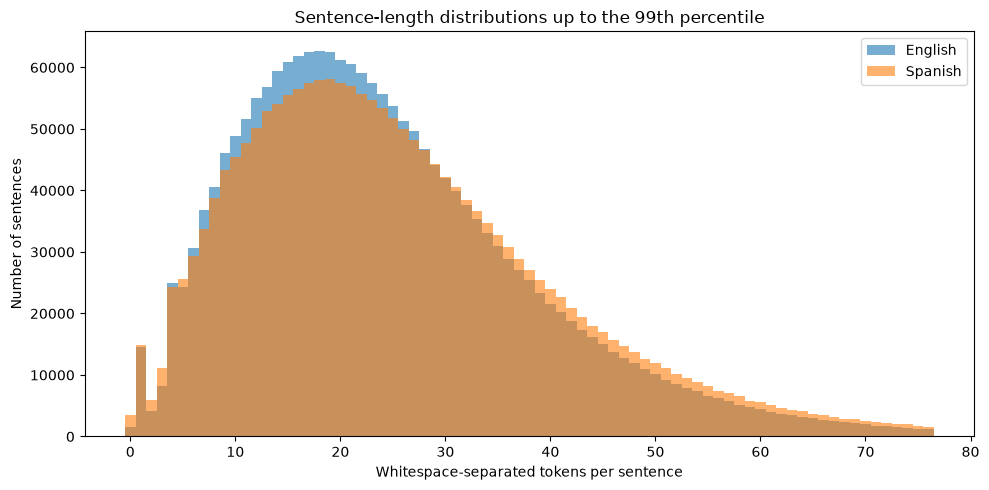

In [13]:
upper = int(np.percentile(np.concatenate([en_tokens, es_tokens]), 99))

integer_bins = np.arange(-0.5, upper + 1.5, 1)

plt.figure(figsize=(10, 5))

plt.hist(
    en_tokens[en_tokens <= upper],
    bins=integer_bins,
    alpha=0.6,
    label="English",
)

plt.hist(
    es_tokens[es_tokens <= upper],
    bins=integer_bins,
    alpha=0.6,
    label="Spanish",
)

plt.xlabel("Whitespace-separated tokens per sentence")
plt.ylabel("Number of sentences")
plt.title("Sentence-length distributions up to the 99th percentile")
plt.legend()
plt.tight_layout()
plt.show()

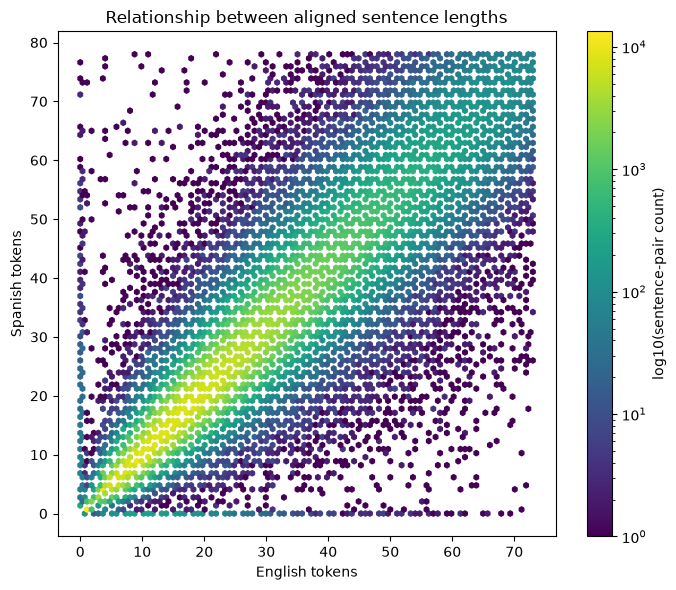

/home/theohagen/Desktop/nlp-machine-translation/plots/task01/aligned_length_relationship.png


In [ ]:
x_limit = int(np.percentile(en_tokens, 99))
y_limit = int(np.percentile(es_tokens, 99))
mask = (en_tokens <= x_limit) & (es_tokens <= y_limit)

plt.figure(figsize=(7, 6))
plt.hexbin(
    en_tokens[mask],
    es_tokens[mask],
    gridsize=70,
    mincnt=1,
    bins="log",
)
plt.xlabel("English tokens")
plt.ylabel("Spanish tokens")
plt.title("Relationship between aligned sentence lengths")
plt.colorbar(label="log10(sentence-pair count)")
plt.tight_layout()

path = PLOT_DIR / "aligned_length_relationship.png"
plt.savefig(path, dpi=200)
plt.show()

print(path)

In [ ]:
lower_diff, upper_diff = np.percentile(token_difference, [1, 99])
difference_mask = (
    (token_difference >= lower_diff)
    & (token_difference <= upper_diff)
)

plt.figure(figsize=(9, 5))
plt.hist(token_difference[difference_mask], bins=60)
plt.axvline(0, linestyle="--", linewidth=1)
plt.xlabel("Spanish token count minus English token count")
plt.ylabel("Number of sentence pairs")
plt.title("Difference in length between aligned sentences")
plt.tight_layout()

path = PLOT_DIR / "token_length_difference.png"
plt.savefig(path, dpi=200)
plt.show()

print(path)

In [ ]:
plot_data = [
    en_tokens[en_tokens <= np.percentile(en_tokens, 99)],
    es_tokens[es_tokens <= np.percentile(es_tokens, 99)],
]

plt.figure(figsize=(7, 5))
plt.boxplot(plot_data, tick_labels=["English", "Spanish"], showfliers=False)
plt.ylabel("Tokens per sentence")
plt.title("English and Spanish sentence lengths")
plt.tight_layout()

path = PLOT_DIR / "token_length_boxplot.png"
plt.savefig(path, dpi=200)
plt.show()

print(path)

## 3. Create the required 10% sample

The same sentence indices are used for both language files, so the parallel alignment is preserved. A fixed random seed makes the selection reproducible without saving an additional index or metadata file.


In [ ]:
sample_size = int(round(total_pairs * SAMPLE_FRACTION))
rng = np.random.default_rng(RANDOM_SEED)

sample_indices = np.sort(
    rng.choice(total_pairs, size=sample_size, replace=False)
)

sample_en_path = SAMPLE_DIR / "europarl_10pct.en"
sample_es_path = SAMPLE_DIR / "europarl_10pct.es"

selected = 0
next_position = 0

with EN_PATH.open("r", encoding="utf-8", errors="replace") as en_file, \
     ES_PATH.open("r", encoding="utf-8", errors="replace") as es_file, \
     sample_en_path.open("w", encoding="utf-8") as sample_en_file, \
     sample_es_path.open("w", encoding="utf-8") as sample_es_file:

    for index, (en_line, es_line) in enumerate(
        tqdm(zip(en_file, es_file), total=total_pairs, desc="Writing 10% sample")
    ):
        if next_position >= sample_size:
            break

        if index == sample_indices[next_position]:
            sample_en_file.write(en_line)
            sample_es_file.write(es_line)
            selected += 1
            next_position += 1

assert selected == sample_size

print(f"Sampled sentence pairs: {selected:,}")
print(f"Saved: {sample_en_path}")
print(f"Saved: {sample_es_path}")


## 4. Findings for the report

After executing the notebook, summarize the most important observations here. Useful points may include:

- the total number of aligned sentence pairs,
- whether empty or XML-like lines occur,
- typical and extreme sentence lengths,
- whether Spanish sentences are generally longer or shorter than their English counterparts,
- how strongly the lengths of aligned sentences correlate,
- whether there are unusual outliers that should be handled during preprocessing.
